In [1]:
#
# How to use your trained model - Deep Learning basics with Python, TensorFlow and Keras
# Steg 6 - Skall nu använda modellen för att uppskatta om det är Katt eller Hund på bilden
#

In [1]:
import cv2
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt      # för att visualisera data
import tensorflow as tf


In [13]:
#
# Bildmtrl för Test av modell, en katt och en hund
# bilder som inte existerar i träningsmaterialet
# Läses in från disk 

DATADIR = "C:\\LTH_data\\photo\\PythUtbPic\\SKARP\\"    # path till katalog med djurbilder
DATADIR_MOD = DATADIR                                   # path till sparad modell

TxT_MODEL_4_fName = DATADIR_MOD + 'steg4_256x3x5-CNN.keras' # Steg 4 anpassad modell
TxT_MODEL_5_fName = DATADIR_MOD + 'steg5-CNN.keras'         # Steg 5 anpassad modell

DATADIR_TEST_CAT = DATADIR + "1pCat\\"                   # path till sparad Katt bild att testa modell
DATADIR_TEST_DOG = DATADIR + "1pDog\\"                   # path till sparad Hund

TxT_fName_Cat = DATADIR_TEST_CAT + "cat.jpg"             # Foto med katt för modelltest
TxT_fName_Dog = DATADIR_TEST_DOG + "dog.jpg"             # Foto med katt

print(f"  {TxT_fName_Cat  =  }")
print(f"  {TxT_fName_Dog  =  }")

print(f"  {TxT_MODEL_4_fName  =  }")
print(f"  {TxT_MODEL_5_fName  =  }")




  TxT_fName_Cat  =  'C:\\LTH_data\\photo\\PythUtbPic\\SKARP\\1pCat\\cat.jpg'
  TxT_fName_Dog  =  'C:\\LTH_data\\photo\\PythUtbPic\\SKARP\\1pDog\\dog.jpg'
  TxT_MODEL_4_fName  =  'C:\\LTH_data\\photo\\PythUtbPic\\SKARP\\steg4_256x3x5-CNN.keras'
  TxT_MODEL_5_fName  =  'C:\\LTH_data\\photo\\PythUtbPic\\SKARP\\steg5-CNN.keras'


In [23]:


CATEGORIES = ["Cat", "Dog"]         # Viktigt med ordningen: "Katter" : 0  &  "Hundar" : 1


def prepare_the_image(filepath):
    print(f"{filepath = }")
    IMG_SIZE = 75
    img_array = cv2.imread(filepath, cv2.IMREAD_GRAYSCALE)
    new_array = cv2.resize(img_array, (IMG_SIZE, IMG_SIZE))
    plt.subplot(1,2,1)
    plt.imshow(img_array, cmap="grey")
    plt.title(f"{img_array.size = }")
    plt.subplot(1,2,2)
    plt.imshow(new_array, cmap="grey")
    plt.title(f"{new_array.size = }")
    plt.show()
    return new_array.reshape(-1, IMG_SIZE, IMG_SIZE, 1)



# prediction = model.predict([prepare_the_image('doggo.jpg')])
# print(prediction)                           # will be a list in a list.
# print(CATEGORIES[int(prediction[0][0])])



In [37]:

# Hämta upp aktuell modell

#model = tf.keras.models.load_model(TxT_MODEL_4_fName)
model = tf.keras.models.load_model(TxT_MODEL_5_fName)


In [39]:
# returnerar AI-modellens classificerade svar

def print_the_response(from_prediction):
    print(f"                  {from_prediction[0][0]   =  }")
    #print(f"              {int(from_prediction[0][0])  =  }")      # funkar inte med int på Python ver 2.9 och  högre, leder till fel svar
    #print(f"   {CATEGORIES[int(from_prediction[0][0])] =  }")      # funkar inte med int på Python ver 2.9 och  högre, leder till fel svar
    print(f"            {round(from_prediction[0][0])  =  }")
    print(f"{CATEGORIES[round(from_prediction[0][0])]  =  }")
    print(f"        Level of possibility to be a Cat ->  {round((1-from_prediction[0][0])*1000)/10} %")
    print(f"        Level of possibility to be a Dog ->  {round((from_prediction[0][0])*1000)/10} %")
    return CATEGORIES[round(from_prediction[0][0])]



filepath = 'C:\\LTH_data\\photo\\PythUtbPic\\SKARP\\1pCat\\cat.jpg'


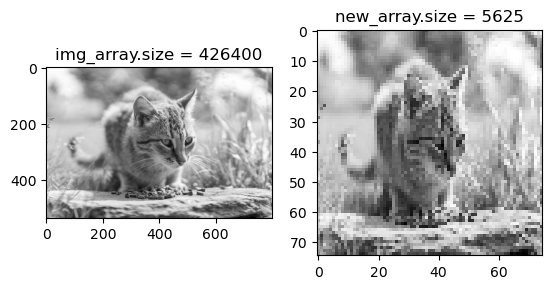

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 134ms/step
                  from_prediction[0][0]   =  0.5464653
            round(from_prediction[0][0])  =  1
CATEGORIES[round(from_prediction[0][0])]  =  'Dog'
        Level of possibility to be a Cat ->  45.4 %
        Level of possibility to be a Dog ->  54.6 %


C:\Users\larth\anaconda3\Lib\site-packages\keras\src\models\functional.py:238: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: input_layer_7
Received: inputs=('Tensor(shape=(1, 75, 75, 1))',)
  warnings.warn(msg)


In [41]:
# Test av modell med en bild på katt
#

pic_array = prepare_the_image(TxT_fName_Cat)
normed_pic_array = pic_array/255.0              # Normera gråskallenivå, (0,255) transformeras till (0,1), utan medlevärdesförskjutning
prediction = model.predict([normed_pic_array])

ans = print_the_response(prediction)



filepath = 'C:\\LTH_data\\photo\\PythUtbPic\\SKARP\\1pDog\\dog.jpg'


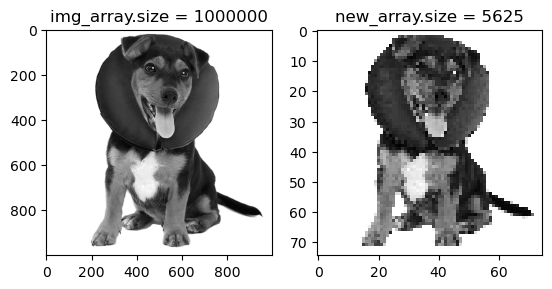

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
                  from_prediction[0][0]   =  0.99431485
            round(from_prediction[0][0])  =  1
CATEGORIES[round(from_prediction[0][0])]  =  'Dog'
        Level of possibility to be a Cat ->  0.6 %
        Level of possibility to be a Dog ->  99.4 %


In [43]:
# Test av modell med en bild på Hund
#

pic_array = prepare_the_image(TxT_fName_Dog)
normed_pic_array = pic_array/255.0              # Normera gråskallenivå, (0,255) transformeras till (0,1), utan medlevärdesförskjutning

ans = print_the_response(model.predict([normed_pic_array]))


In [9]:
CATEGORIES

['Cat', 'Dog']

In [22]:
print(f"{CATEGORIES[0] = }\t\t{CATEGORIES[1] = }")

CATEGORIES[0] = 'Cat'		CATEGORIES[1] = 'Dog'
